In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [2]:
FEATURE_COUNT = 3690

In [3]:
# Load dataset, using float32 dtype for float columns
dtypes = {f'f{i}': np.float32 for i in range(FEATURE_COUNT)}

int_colums = ['cell_number']
for c in int_colums:
    dtypes[c] = np.int64

object_columns = ['label', 'image_path', 'cell_image_path']
for c in object_columns:
    dtypes[c] = object

df = pd.read_csv('data/final_data/train_data.csv', dtype=dtypes)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14573 entries, 0 to 14572
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   file_name        14573 non-null  object
 1   image_path       14573 non-null  object
 2   cell_number      14573 non-null  int64 
 3   cell_image_path  14573 non-null  object
 4   label            14573 non-null  object
dtypes: int64(1), object(4)
memory usage: 569.4+ KB


In [5]:
df.columns

Index(['file_name', 'image_path', 'cell_number', 'cell_image_path', 'label'], dtype='object')

In [6]:
def display_sample_images(df, label, sample_size, images_per_row=5):
    """
    Display randomly chosen cell images for a specific class label in a grid layout.
    
    Parameters:
    - df: DataFrame containing the data
    - label: The class label to filter by
    - sample_size: Number of images to display
    - images_per_row: Number of images per row (default: 5)
    """
    # Filter dataframe by label
    label_df = df[df['label'] == label]
    
    if len(label_df) == 0:
        print(f"No images found for label {label}")
        return
    
    # Sample randomly
    sample_size = min(sample_size, len(label_df))
    sampled_df = label_df.sample(n=sample_size, random_state=None)
    
    # Calculate grid dimensions
    n_rows = (sample_size + images_per_row - 1) // images_per_row
    
    # Create figure
    fig, axes = plt.subplots(n_rows, images_per_row, figsize=(15, 3 * n_rows))
    
    # Flatten axes array for easier iteration
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    # Display images
    for idx, (_, row) in enumerate(sampled_df.iterrows()):
        img_path = row['cell_image_path']
        try:
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(f"Cell {row['cell_number']}", fontsize=10)
            axes[idx].axis('off')
        except Exception as e:
            axes[idx].text(0.5, 0.5, f"Error loading\n{img_path}", 
                          ha='center', va='center', fontsize=8)
            axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(sample_size, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f"Sample Images for Label {label} (n={sample_size})", fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

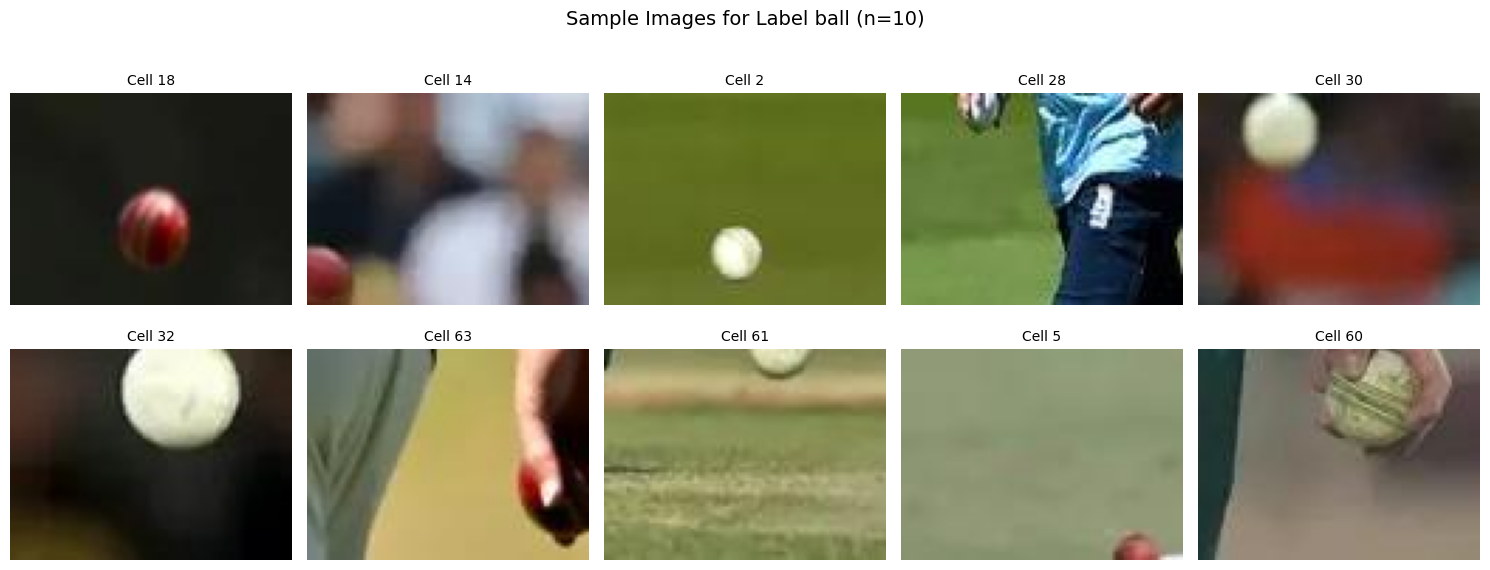

In [8]:
display_sample_images(df, label='ball', sample_size=10)